In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Configuration
IMG_SIZE = (120, 120)
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20

In [2]:
# 2. Load Datasets
# This automatically uses folder names as labels
train_ds = tf.keras.utils.image_dataset_from_directory(
    './Train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Use 'sparse' if you prefer integer labels
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    './Test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
# Get class names for reference
class_names = train_ds.class_names
num_classes = len(class_names)

# Optimize performance by buffering data from disk
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 386 files belonging to 17 classes.
Found 107 files belonging to 17 classes.


In [3]:
# 3. Build the CNN Model
model = models.Sequential([
    # Rescaling layer to normalize pixel values [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
    
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Helps prevent overfitting
    layers.Dense(num_classes, activation='softmax')
])

C:\Users\Davea\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# 4. Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 118, 118, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,864,465 (10.93 MB)

 Trainable params: 2,864,465 (10.93 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. Train the Model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.1528 - loss: 2.7546 - val_accuracy: 0.1121 - val_loss: 2.7519
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.1736 - loss: 2.6266 - val_accuracy: 0.1308 - val_loss: 2.7226
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.2513 - loss: 2.5017 - val_accuracy: 0.1869 - val_loss: 2.7450
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.3316 - loss: 2.2152 - val_accuracy: 0.1869 - val_loss: 2.6961
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - accuracy: 0.3601 - loss: 2.0219 - val_accuracy: 0.1869 - val_loss: 2.6937
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.4896 - loss: 1.6316 - val_accuracy: 0.2056 - val_loss: 2.9484
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.6399 - loss: 1.2376 - val_accuracy: 0.1402 - val_loss: 3.1828
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.6321 - loss: 1.0770 - val_accuracy: 0.

In [6]:
# 6. Evaluate and Save
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# model.save('pokemon_classifier_model.h5')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1589 - loss: 5.2586

Test Accuracy: 15.89%


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50

# 1. Configuration
IMG_SIZE = (120, 120)
BATCH_SIZE = 32
EPOCHS = 15  # Transfer learning usually converges faster

# 2. Data Loading & Augmentation
# ResNet50 expects specific preprocessing; we'll use a Lambda layer for that.
train_ds = tf.keras.utils.image_dataset_from_directory(
    './train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    './test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

num_classes = len(train_ds.class_names)

# 3. Build the Model using ResNet50
# We exclude the top (the original 1000-class classifier) to add our own.
base_model = ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(120, 120, 3)
)

# Freeze the base model so we don't destroy the pre-trained weights
base_model.trainable = False

model = models.Sequential([
    # ResNet50 requires specific input scaling (-1 to 1 or similar)
    # This utility function handles it automatically for ResNet
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input, input_shape=(120, 120, 3)),
    
    base_model,
    
    # Global Average Pooling reduces the 4x4x2048 output to a 2048 vector
    layers.GlobalAveragePooling2D(),
    
    # Custom classifier head
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# 4. Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train (Phase 1: Training only the top layers)
print("Starting training of the custom classifier head...")
model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

# 6. Fine-Tuning (Phase 2: Optional)
# Unfreeze the base model to tweak it slightly for Pokemon features
base_model.trainable = True

# Important: Use a much smaller learning rate for fine-tuning
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting fine-tuning of the entire model...")
model.fit(train_ds, validation_data=test_ds, epochs=5)

# 7. Final Evaluation
loss, accuracy = model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

Found 386 files belonging to 17 classes.
Found 107 files belonging to 17 classes.


C:\Users\Davea\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Starting training of the custom classifier head...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 568ms/step - accuracy: 0.1373 - loss: 3.5908 - val_accuracy: 0.1402 - val_loss: 2.8566
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 414ms/step - accuracy: 0.3549 - loss: 2.1107 - val_accuracy: 0.2243 - val_loss: 2.9105
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 525ms/step - accuracy: 0.5155 - loss: 1.6228 - val_accuracy: 0.2056 - val_loss: 2.6443
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 445ms/step - accuracy: 0.6062 - loss: 1.3401 - val_accuracy: 0.1869 - val_loss: 2.8102
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.6632 - loss: 1.1207 - val_accuracy: 0.2243 - val_loss: 2.8114
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.7824 - loss: 0.7995 - val_accuracy: 0.2243 - val_loss: 2.8402
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.7850 - loss: 0.7478 - val_accuracy: 0.2991 - val_loss: 3.0968
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 407ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


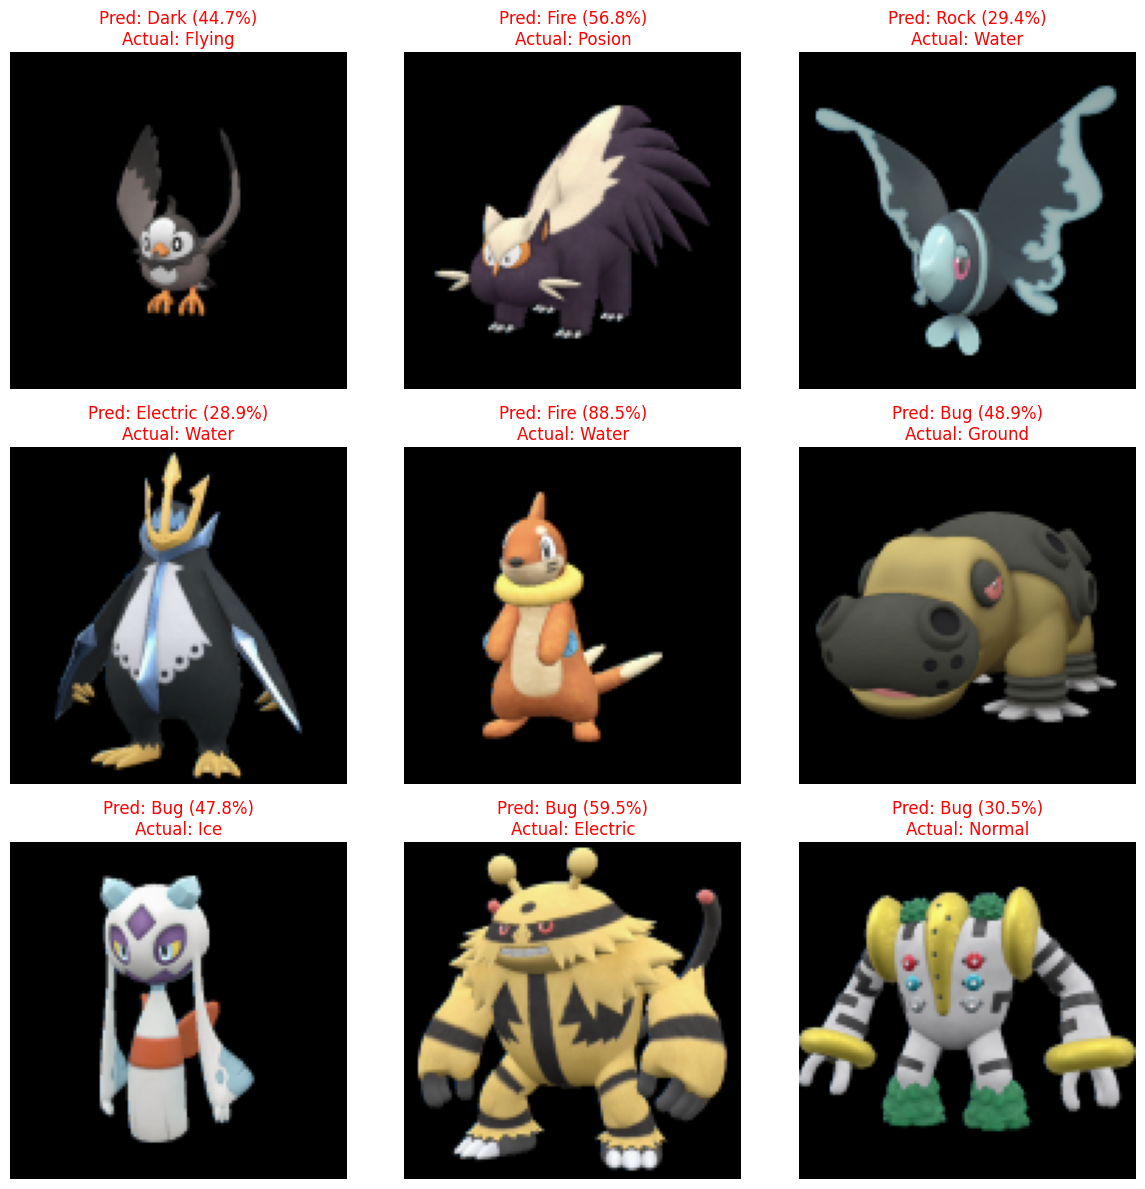

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, class_names, num_images=9):
    # Grab one batch from the test dataset
    images, labels = next(iter(dataset.take(2)))
    
    # Generate predictions
    # Note: ResNet50 preprocessing is handled inside the model's Lambda layer
    predictions = model.predict(images)
    
    plt.figure(figsize=(12, 12))
    
    for i in range(min(num_images, len(images))):
        plt.subplot(3, 3, i + 1)
        
        # Display the image
        # We cast to uint8 for display because ResNet preprocessing 
        # can make values look weird if plotted directly
        display_img = images[i].numpy().astype("uint8")
        plt.imshow(display_img)
        
        # Get indices of the highest probability
        pred_idx = np.argmax(predictions[i])
        actual_idx = np.argmax(labels[i])
        
        pred_label = class_names[pred_idx]
        actual_label = class_names[actual_idx]
        confidence = 100 * np.max(predictions[i])
        
        # Color code: Green if correct, Red if wrong
        color = 'green' if pred_idx == actual_idx else 'red'
        
        plt.title(f"Pred: {pred_label} ({confidence:.1f}%)\nActual: {actual_label}", color=color)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# --- Usage ---
# Ensure you have class_names from your dataset setup
# class_names = train_ds.class_names

visualize_predictions(model, test_ds, class_names)